In [89]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from collections import Counter
import os


In [90]:
# load data
df = pd.read_csv('../outputs/cleaned_text_data.csv')

# word cloud

In [91]:
catholic_text = ' '.join(df[df['religious_group'] == 'catholic']['cleaned_content'].dropna())
protestant_text = ' '.join(df[df['religious_group'] == 'protestant']['cleaned_content'].dropna())

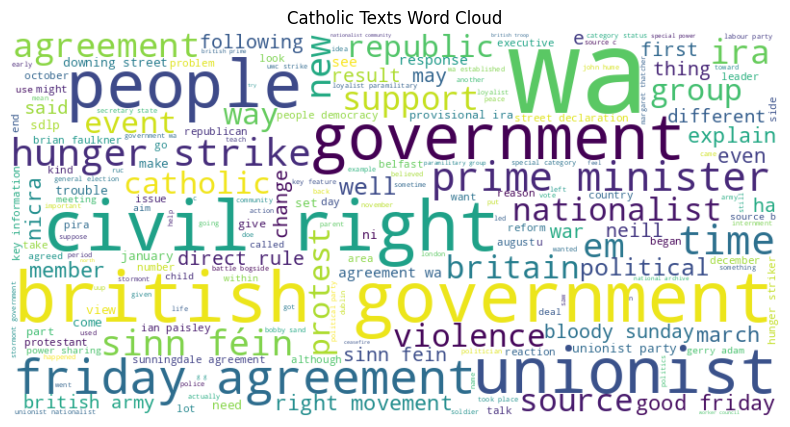

In [92]:
# Catholic word cloud
wc_catholic = WordCloud(width=800, height=400, background_color='white').generate(catholic_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc_catholic, interpolation='bilinear')
plt.axis('off')
plt.title('Catholic Texts Word Cloud')
plt.show()

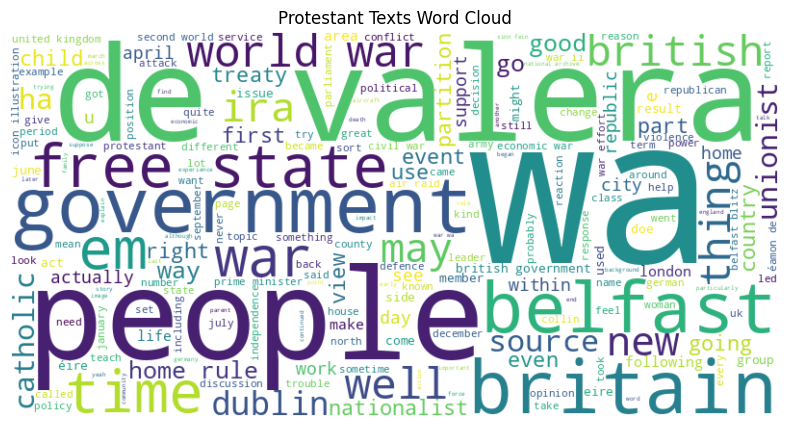

In [93]:
# Protestant word cloud
wc_protestant = WordCloud(width=800, height=400, background_color='white').generate(protestant_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc_protestant, interpolation='bilinear')
plt.axis('off')
plt.title('Protestant Texts Word Cloud')
plt.show()

# TFIDF


In [94]:
# Debug: Check what's in the texts
print("\n=== DEBUG INFO ===")
if len(catholic_text) > 0:
    print(f"Catholic text sample: {catholic_text[:200]}")
    print(f"Catholic text length: {len(catholic_text)}")
else:
    print("No Catholic text found!")

if len(protestant_text) > 0:
    print(f"Protestant text sample: {protestant_text[:200]}")
    print(f"Protestant text length: {len(protestant_text)}")
else:
    print("No Protestant text found!")




=== DEBUG INFO ===
Catholic text sample: relation republic emergence development wa established government act act partitioned county southern later became free state population reacted new arrangement unionist mostly protestant delighted ne
Catholic text length: 1638893
Protestant text sample: e okay place since mean taught sort sector recently since eotas young people whose mainstream place broken social emotional difficulty taught belfast lisburn also spent working outdoor pursuit instruc
Protestant text length: 1135803


In [95]:
# Function to get top TF-IDF weighted n-grams
def get_top_tfidf_ngrams(text, ngram_range=(1, 1), top_n=20):
    """Get top n-grams based on TF-IDF scores"""
    
    vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
    
    # Debug: check if we have any content
    print(f"Text length: {len(text)}")
    print(f"First 200 characters: {text[:200]}")
    
    # Check if text is mostly whitespace or empty
    if len(text.strip()) == 0:
        print("Warning: Text is empty or only whitespace!")
        return []
    
    try:
        tfidf_matrix = vectorizer.fit_transform([text])
        feature_names = vectorizer.get_feature_names_out()
        
        print(f"Number of features found: {len(feature_names)}")
        if len(feature_names) > 0:
            print(f"First 10 features: {feature_names[:10]}")
        
        if len(feature_names) == 0:
            print("Warning: No features found. Trying without stopwords...")
            vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
            tfidf_matrix = vectorizer.fit_transform([text])
            feature_names = vectorizer.get_feature_names_out()
            print(f"Features without stopwords: {len(feature_names)}")
        
        # Get TF-IDF scores
        tfidf_sums = np.array(tfidf_matrix.sum(axis=0)).flatten()
        top_indices = tfidf_sums.argsort()[-top_n:][::-1]
        top_ngrams = [(feature_names[i], tfidf_sums[i]) for i in top_indices]
        return top_ngrams
        
    except ValueError as e:
        print(f"Error in TF-IDF processing: {e}")
        print("Trying without any stopwords...")
        vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
        tfidf_matrix = vectorizer.fit_transform([text])
        feature_names = vectorizer.get_feature_names_out()
        
        # Get TF-IDF scores
        tfidf_sums = np.array(tfidf_matrix.sum(axis=0)).flatten()
        top_indices = tfidf_sums.argsort()[-top_n:][::-1]
        top_ngrams = [(feature_names[i], tfidf_sums[i]) for i in top_indices]
        return top_ngrams

In [96]:
# Analyze Catholic texts
print("\n=== CATHOLIC TEXTS ANALYSIS ===")

# TF-IDF for unigrams
print("Building TF-IDF for Catholic texts...")
catholic_top_terms = get_top_tfidf_ngrams(catholic_text, ngram_range=(1, 1), top_n=20)

print("\nTop 20 terms in Catholic texts:")
for term, score in catholic_top_terms:
    print(f"{term}: {score:.4f}")

# TF-IDF for bigrams
catholic_top_bigrams = get_top_tfidf_ngrams(catholic_text, ngram_range=(2, 2), top_n=20)

print("\nTop 20 bigrams in Catholic texts:")
for bigram, score in catholic_top_bigrams:
    print(f"{bigram}: {score:.4f}")



=== CATHOLIC TEXTS ANALYSIS ===
Building TF-IDF for Catholic texts...
Text length: 1638893
First 200 characters: relation republic emergence development wa established government act act partitioned county southern later became free state population reacted new arrangement unionist mostly protestant delighted ne
Number of features found: 1000
First 10 features: ['able' 'accept' 'accepted' 'accessibility' 'account' 'achieve' 'achieved'
 'across' 'act' 'action']

Top 20 terms in Catholic texts:
wa: 0.5244
government: 0.2324
unionist: 0.2021
agreement: 0.1912
british: 0.1633
people: 0.1396
ira: 0.1273
nationalist: 0.1264
party: 0.1154
right: 0.1150
source: 0.1032
new: 0.1019
strike: 0.0969
violence: 0.0952
march: 0.0946
political: 0.0941
support: 0.0930
civil: 0.0896
catholic: 0.0867
may: 0.0848
Text length: 1638893
First 200 characters: relation republic emergence development wa established government act act partitioned county southern later became free state population reacted new arr

In [97]:
# Analyze Protestant texts
print("\n=== PROTESTANT TEXTS ANALYSIS ===")

# TF-IDF for unigrams
print("Building TF-IDF for Protestant texts...")
protestant_top_terms = get_top_tfidf_ngrams(protestant_text, ngram_range=(1, 1), top_n=20)

print("\nTop 20 terms in Protestant texts:")
for term, score in protestant_top_terms:
    print(f"{term}: {score:.4f}")

# TF-IDF for bigrams
protestant_top_bigrams = get_top_tfidf_ngrams(protestant_text, ngram_range=(2, 2), top_n=20)

print("\nTop 20 bigrams in Protestant texts:")
for bigram, score in protestant_top_bigrams:
    print(f"{bigram}: {score:.4f}")


=== PROTESTANT TEXTS ANALYSIS ===
Building TF-IDF for Protestant texts...
Text length: 1135803
First 200 characters: e okay place since mean taught sort sector recently since eotas young people whose mainstream place broken social emotional difficulty taught belfast lisburn also spent working outdoor pursuit instruc
Number of features found: 1000
First 10 features: ['ability' 'able' 'academy' 'accept' 'accepted' 'access' 'accessibility'
 'according' 'account' 'across']

Top 20 terms in Protestant texts:
wa: 0.5378
war: 0.2921
government: 0.1788
british: 0.1690
britain: 0.1518
state: 0.1498
people: 0.1466
belfast: 0.1297
de: 0.1149
valera: 0.1133
source: 0.1039
free: 0.0968
time: 0.0944
home: 0.0921
like: 0.0919
treaty: 0.0878
em: 0.0871
new: 0.0797
world: 0.0797
also: 0.0778
Text length: 1135803
First 200 characters: e okay place since mean taught sort sector recently since eotas young people whose mainstream place broken social emotional difficulty taught belfast lisburn also spent w